Part 1: Training a Model


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model trained!
Learned weight: 0.4398 (true: 0.7)
Learned bias: 0.3607 (true: 0.3)

Part 2: Making Predictions
Model set to evaluation mode

Test predictions (first 5):
  X: tensor([0.8400, 0.8600, 0.8800, 0.9000, 0.9200])
  Predicted: tensor([0.7302, 0.7390, 0.7478, 0.7566, 0.7654])
  Actual: tensor([0.8880, 0.9020, 0.9160, 0.9300, 0.9440])

Test Loss (MSE): 0.0311

Part 3: Visualizing Predictions


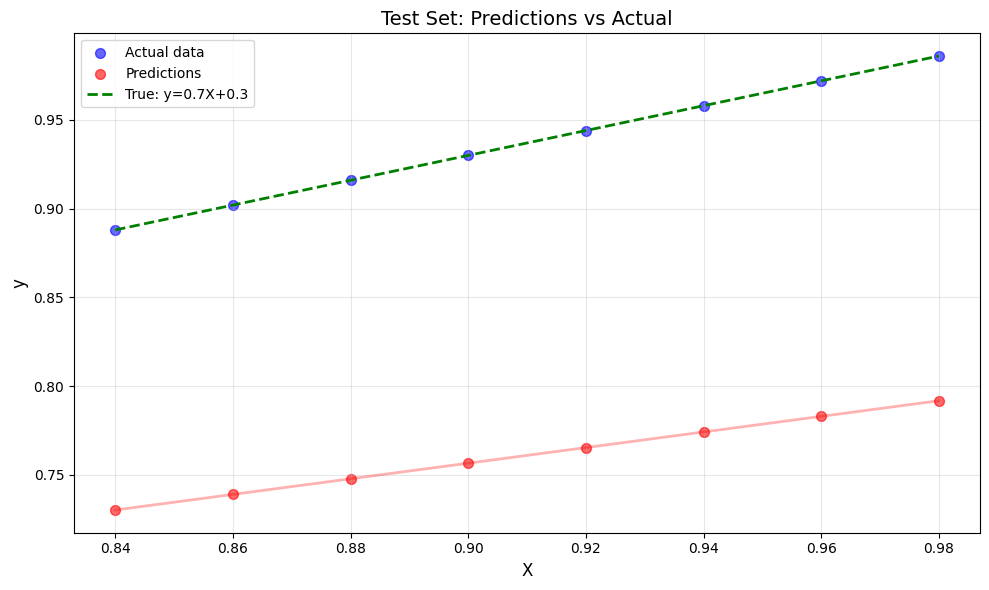

Predictions visualized!

Part 4: Saving the Model
Model saved to: saved_models/linear_model.pth
File size: 1526 bytes

Part 5: Loading the Model
Created new model instance
Parameters before loading:
  Weight: 0.2345
  Bias: 0.2303

Parameters after loading:
  Weight: 0.4398
  Bias: 0.3607

Verification:
  Test Loss: 0.0311
  Matches original: True

Part 6: Saving Complete Checkpoints
Checkpoint saved to: saved_models/checkpoint.tar
Checkpoint contents:
  epoch
  model_state_dict
  optimizer_state_dict
  train_loss
  val_loss
  test_loss
  hyperparameters
  timestamp
  pytorch_version

Part 7: Loading from Checkpoint
Loaded checkpoint from epoch 100
Train loss: 0.0035
Val loss: 0.0189
Test loss: 0.0311
Hyperparameters: {'learning_rate': 0.01, 'weight': 0.7, 'bias': 0.3}

Model and optimizer restored successfully!

Exercises

Exercise 1: Save multiple model versions
Tip: Use f-strings for filenames: f'model_lr{lr}.pth'

Exercise 2: Inference on new data
Tip: Try X values like -0.5, 1.5 (

In [2]:
"""
Exercise 4: Inference and Model Saving
PyTorch Workflow Fundamentals - Module 2

This exercise covers:
- Making predictions in inference mode
- Understanding model.eval() and torch.no_grad()
- Saving model state
- Loading saved models
- Evaluating on test data

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import datetime

# Set random seed for reproducibility
torch.manual_seed(42)

# ============================================
# Part 1: Train a Model (Quick Setup)
# ============================================

print("=" * 60)
print("Part 1: Training a Model")
print("=" * 60)

# TODO: Setup data
weight = 0.7
bias = 0.3
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

train_split = int(0.7 * len(X))
val_split = int(0.85 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]
X_test, y_test = X[val_split:], y[val_split:]

# TODO: Create and train model


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weight * x + self.bias


model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Quick training
epochs = 100
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Model trained!")
print(f"Learned weight: {model.weight.item():.4f} (true: {weight})")
print(f"Learned bias: {model.bias.item():.4f} (true: {bias})")

# ============================================
# Part 2: Making Predictions in Inference Mode
# ============================================

print("\n" + "=" * 60)
print("Part 2: Making Predictions")
print("=" * 60)

# TODO: Set model to evaluation mode
model.eval()
print("Model set to evaluation mode")

# TODO: Make predictions on test data
with torch.no_grad():
    test_predictions = model(X_test)

print(f"\nTest predictions (first 5):")
print(f"  X: {X_test[:5].flatten()}")
print(f"  Predicted: {test_predictions[:5].flatten()}")
print(f"  Actual: {y_test[:5].flatten()}")

# TODO: Calculate test loss
test_loss = criterion(test_predictions, y_test)
print(f"\nTest Loss (MSE): {test_loss.item():.4f}")

# ============================================
# Part 3: Visualizing Predictions
# ============================================

print("\n" + "=" * 60)
print("Part 3: Visualizing Predictions")
print("=" * 60)

# TODO: Plot test predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, c='b', s=50, alpha=0.6, label='Actual data')
plt.scatter(X_test, test_predictions, c='r', s=50, alpha=0.6, label='Predictions')
plt.plot(X_test, test_predictions, 'r-', linewidth=2, alpha=0.3)
plt.plot(X_test, weight * X_test + bias, 'g--', linewidth=2, label=f'True: y={weight}X+{bias}')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=10)
plt.title('Test Set: Predictions vs Actual', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Predictions visualized!")

# ============================================
# Part 4: Saving the Model
# ============================================

print("\n" + "=" * 60)
print("Part 4: Saving the Model")
print("=" * 60)

# TODO: Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# TODO: Save model state dict
model_path = 'saved_models/linear_model.pth'
torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

# TODO: Verify file was created
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path)
    print(f"File size: {file_size} bytes")
else:
    print("Error: File was not created!")

# ============================================
# Part 5: Loading the Model
# ============================================

print("\n" + "=" * 60)
print("Part 5: Loading the Model")
print("=" * 60)

# TODO: Create new model instance
loaded_model = LinearRegressionModel()
print("Created new model instance")
print(f"Parameters before loading:")
print(f"  Weight: {loaded_model.weight.item():.4f}")
print(f"  Bias: {loaded_model.bias.item():.4f}")

# TODO: Load saved state
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

print(f"\nParameters after loading:")
print(f"  Weight: {loaded_model.weight.item():.4f}")
print(f"  Bias: {loaded_model.bias.item():.4f}")

# TODO: Verify loaded model works
with torch.no_grad():
    loaded_predictions = loaded_model(X_test)
    verification_loss = criterion(loaded_predictions, y_test)

print(f"\nVerification:")
print(f"  Test Loss: {verification_loss.item():.4f}")
print(f"  Matches original: {torch.allclose(test_predictions, loaded_predictions)}")

# ============================================
# Part 6: Saving Complete Checkpoints
# ============================================

print("\n" + "=" * 60)
print("Part 6: Saving Complete Checkpoints")
print("=" * 60)

# TODO: Create checkpoint dictionary
checkpoint = {
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': criterion(model(X_train), y_train).item(),
    'val_loss': criterion(model(X_val), y_val).item(),
    'test_loss': test_loss.item(),
    'hyperparameters': {
        'learning_rate': 0.01,
        'weight': weight,
        'bias': bias
    },
    'timestamp': datetime.datetime.now().isoformat(),
    'pytorch_version': torch.__version__,
}

# TODO: Save checkpoint
# Note: .tar is the PyTorch convention for checkpoints (contains more than just state_dict)
checkpoint_path = 'saved_models/checkpoint.tar'
torch.save(checkpoint, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")
print(f"Checkpoint contents:")
for key in checkpoint.keys():
    print(f"  {key}")

# ============================================
# Part 7: Loading from Checkpoint
# ============================================

print("\n" + "=" * 60)
print("Part 7: Loading from Checkpoint")
print("=" * 60)

# TODO: Load checkpoint
loaded_checkpoint = torch.load(checkpoint_path)

print(f"Loaded checkpoint from epoch {loaded_checkpoint['epoch']}")
print(f"Train loss: {loaded_checkpoint['train_loss']:.4f}")
print(f"Val loss: {loaded_checkpoint['val_loss']:.4f}")
print(f"Test loss: {loaded_checkpoint['test_loss']:.4f}")
print(f"Hyperparameters: {loaded_checkpoint['hyperparameters']}")

# TODO: Restore model and optimizer
restored_model = LinearRegressionModel()
restored_model.load_state_dict(loaded_checkpoint['model_state_dict'])
restored_model.eval()

restored_optimizer = optim.SGD(restored_model.parameters(), lr=0.01)
restored_optimizer.load_state_dict(loaded_checkpoint['optimizer_state_dict'])

print("\nModel and optimizer restored successfully!")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Multiple model versions
print("\nExercise 1: Save multiple model versions")
# TODO: Train models with different learning rates
# TODO: Save each with a different name
# TODO: Load and compare them
print("Tip: Use f-strings for filenames: f'model_lr{lr}.pth'")

# Exercise 2: Inference on new data
print("\nExercise 2: Inference on new data")
# TODO: Create new data points outside training range
# TODO: Make predictions
# TODO: Discuss extrapolation
print("Tip: Try X values like -0.5, 1.5 (outside 0-1 range)")

# Exercise 3: Model comparison
print("\nExercise 3: Model comparison")
# TODO: Load multiple saved models
# TODO: Compare their predictions
# TODO: Visualize all on same plot
print("Tip: Plot multiple learned lines on one graph")

# Exercise 4: Save training history
print("\nExercise 4: Save training history")
# TODO: Save loss curves with checkpoint
# TODO: Load and plot training history
# TODO: Compare multiple training runs
print("Tip: Add 'train_losses': train_losses to checkpoint")

# Exercise 5: Resume training
print("\nExercise 5: Resume training")
# TODO: Load checkpoint
# TODO: Continue training from saved epoch
# TODO: Verify it continues correctly
print("Tip: Use checkpoint['epoch'] as starting point")

print("\n" + "=" * 60)
print("Exercise 4 Complete!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Multiple model versions
- TODO: Train models with different learning rates
- TODO: Save each with a different name
- TODO: Load and compare them

lr=0.001: weight=2.2219, bias=-0.5613, test_loss=0.279047
lr=0.01: weight=0.5087, bias=0.3554, test_loss=0.014171
lr=0.1: weight=0.5524, bias=0.3521, test_loss=0.006807


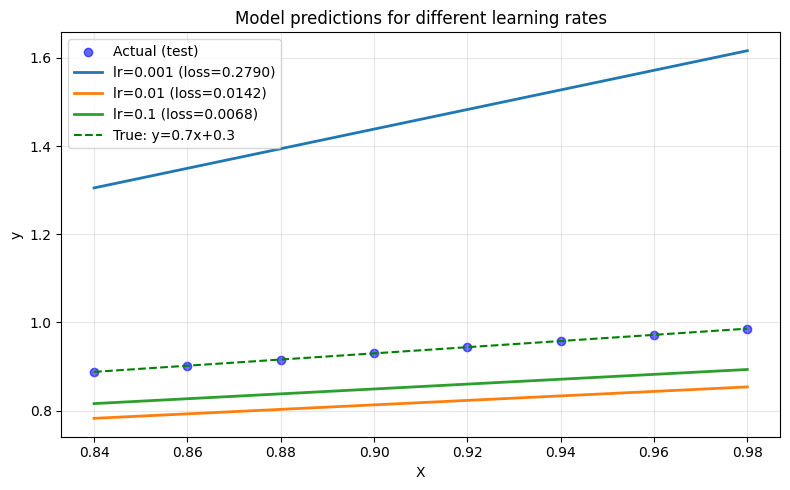

In [3]:
learning_rates = [0.001, 0.01, 0.1]
models_info = {}

for lr in learning_rates:
    # new model and optimizer for each lr
    m = LinearRegressionModel()
    opt = optim.SGD(m.parameters(), lr=lr)

    # train quickly
    for epoch in range(epochs):
        m.train()
        preds = m(X_train)
        loss = criterion(preds, y_train)
        opt.zero_grad()
        loss.backward()
        opt.step()

    # save with lr in filename (dot replaced to keep filenames clean)
    fname = f"saved_models/model_lr{str(lr).replace('.', 'p')}.pth"
    torch.save(m.state_dict(), fname)
    models_info[lr] = {'path': fname}

# Load saved models, evaluate on test set, and plot comparisons
plt.figure(figsize=(8, 5))
plt.scatter(X_test.numpy(), y_test.numpy(), c='b', label='Actual (test)', alpha=0.6)

for lr, info in models_info.items():
    loaded = LinearRegressionModel()
    loaded.load_state_dict(torch.load(info['path']))
    loaded.eval()
    with torch.no_grad():
        preds = loaded(X_test)
        test_l = criterion(preds, y_test).item()
    print(f"lr={lr}: weight={loaded.weight.item():.4f}, bias={loaded.bias.item():.4f}, test_loss={test_l:.6f}")
    plt.plot(X_test.numpy(), preds.numpy(), linewidth=2, label=f"lr={lr} (loss={test_l:.4f})")

# true line for reference
plt.plot(X_test.numpy(), (weight * X_test + bias).numpy(), 'g--', label=f"True: y={weight}x+{bias}")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Model predictions for different learning rates')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Exercise 2: Inference on new data
- TODO: Create new data points outside training range
- TODO: Make predictions
- TODO: Discuss extrapolation

X_new: [-0.5, -0.25, 0.0, 0.5, 1.0, 1.5]
Predictions: [0.14082489907741547, 0.250779390335083, 0.36073386669158936, 0.580642819404602, 0.8005517721176147, 1.020460844039917]
True (y = 0.7*x + 0.3): [-0.04999998211860657, 0.1250000149011612, 0.30000001192092896, 0.6499999761581421, 1.0, 1.3499999046325684]


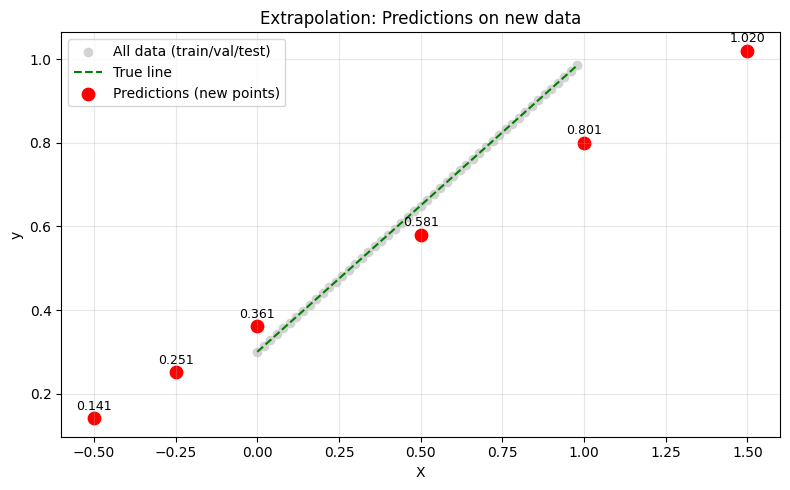

Note: These are extrapolations. 
The linear model assumes the same linear relationship outside the training range; predictions become less reliable further from the training data.


In [4]:
X_new = torch.tensor([-0.5, -0.25, 0.0, 0.5, 1.0, 1.5]).unsqueeze(1)

loaded_model.eval()
with torch.no_grad():
    preds_new = loaded_model(X_new)
    true_new = weight * X_new + bias

print("X_new:", X_new.flatten().tolist())
print("Predictions:", preds_new.flatten().tolist())
print("True (y = 0.7*x + 0.3):", true_new.flatten().tolist())

# Quick visualization: dataset, true line, and new predictions
plt.figure(figsize=(8,5))
plt.scatter(X.numpy(), y.numpy(), c='lightgray', label='All data (train/val/test)')
plt.plot(X.numpy(), (weight * X + bias).numpy(), 'g--', label='True line')
plt.scatter(X_new.numpy(), preds_new.numpy(), c='red', s=80, label='Predictions (new points)')
for x, p, t in zip(X_new.flatten().numpy(), preds_new.flatten().numpy(), true_new.flatten().numpy()):
    plt.annotate(f"{p:.3f}", (x, p), textcoords="offset points", xytext=(0,6), ha='center', fontsize=9)
plt.xlabel('X'); plt.ylabel('y'); plt.title('Extrapolation: Predictions on new data')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Note on extrapolation
print("Note: These are extrapolations. \nThe linear model assumes the same linear relationship outside the training range; predictions become less reliable further from the training data.")

# Exercise 3: Model comparison
- TODO: Load multiple saved models
- TODO: Compare their predictions
- TODO: Visualize all on same plot

lr=0.001: weight=2.2219, bias=-0.5613, test_loss=0.279047
lr=0.01: weight=0.5087, bias=0.3554, test_loss=0.014171
lr=0.1: weight=0.5524, bias=0.3521, test_loss=0.006807


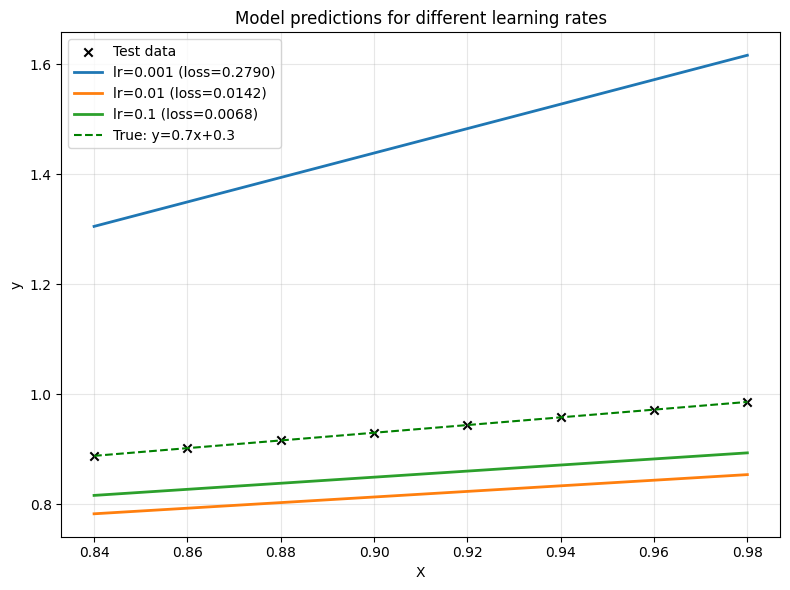

In [5]:
# Load saved models, compare their predictions on X_test, and visualize all on one plot
preds_dict = {}
plt.figure(figsize=(8, 6))
plt.scatter(X_test.numpy(), y_test.numpy(), c='k', marker='x', label='Test data')

colors = plt.cm.tab10.colors
for i, (lr, info) in enumerate(models_info.items()):
    mdl = LinearRegressionModel()
    mdl.load_state_dict(torch.load(info['path']))
    mdl.eval()
    with torch.no_grad():
        p = mdl(X_test)
    loss_i = criterion(p, y_test).item()
    preds_dict[lr] = p
    print(f"lr={lr}: weight={mdl.weight.item():.4f}, bias={mdl.bias.item():.4f}, test_loss={loss_i:.6f}")
    plt.plot(X_test.numpy(), p.numpy(), color=colors[i % len(colors)], linewidth=2, label=f"lr={lr} (loss={loss_i:.4f})")

# True line for reference
plt.plot(X_test.numpy(), (weight * X_test + bias).numpy(), 'g--', label=f"True: y={weight}x+{bias}")
plt.xlabel('X'); plt.ylabel('y'); plt.title('Model predictions for different learning rates')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Exercise 4: Save training history
- TODO: Save loss curves with checkpoint
- TODO: Load and plot training history
- TODO: Compare multiple training runs

Checkpoint saved for lr=0.001: saved_models/checkpoint_lr0p001.tar
Checkpoint saved for lr=0.01: saved_models/checkpoint_lr0p01.tar
Checkpoint saved for lr=0.1: saved_models/checkpoint_lr0p1.tar


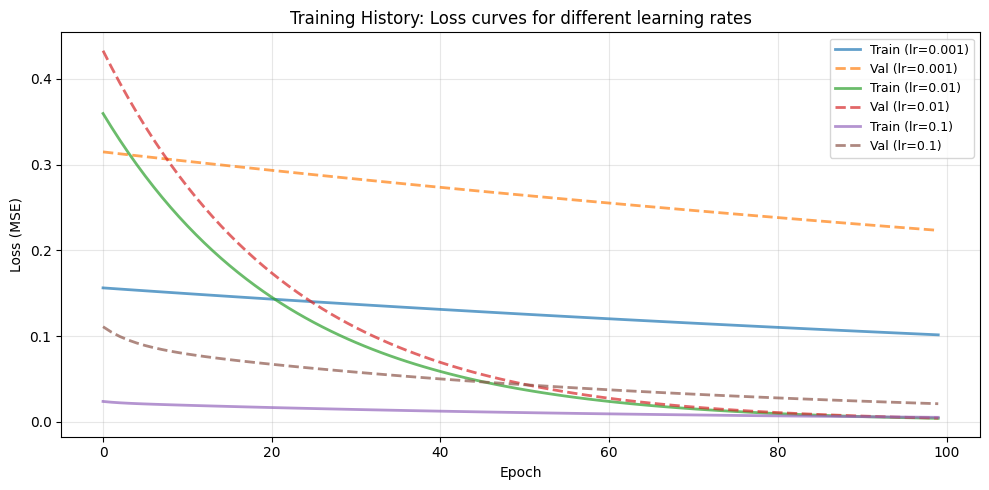

Training history loaded and compared!


In [6]:
# Train models with different learning rates and save training history
train_losses_dict = {}
val_losses_dict = {}

for lr in learning_rates:
    m = LinearRegressionModel()
    opt = optim.SGD(m.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    # Train and track losses
    for epoch in range(epochs):
        m.train()
        preds = m(X_train)
        loss = criterion(preds, y_train)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_losses.append(loss.item())
        
        # Validation loss
        m.eval()
        with torch.no_grad():
            val_preds = m(X_val)
            val_loss = criterion(val_preds, y_val)
        val_losses.append(val_loss.item())
    
    train_losses_dict[lr] = train_losses
    val_losses_dict[lr] = val_losses
    
    # Save checkpoint with training history
    checkpoint_lr = {
        'epoch': epochs,
        'lr': lr,
        'model_state_dict': m.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
    }
    
    checkpoint_path_lr = f'saved_models/checkpoint_lr{str(lr).replace(".", "p")}.tar'
    torch.save(checkpoint_lr, checkpoint_path_lr)
    print(f"Checkpoint saved for lr={lr}: {checkpoint_path_lr}")

# Load and plot training history for all models
plt.figure(figsize=(10, 5))
for i, lr in enumerate(learning_rates):
    checkpoint_path_lr = f'saved_models/checkpoint_lr{str(lr).replace(".", "p")}.tar'
    loaded_ckpt = torch.load(checkpoint_path_lr)
    train_losses = loaded_ckpt['train_losses']
    val_losses = loaded_ckpt['val_losses']
    
    plt.plot(train_losses, label=f'Train (lr={lr})', linewidth=2, alpha=0.7)
    plt.plot(val_losses, label=f'Val (lr={lr})', linewidth=2, linestyle='--', alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History: Loss curves for different learning rates')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Training history loaded and compared!")

# Exercise 5: Resume training
- TODO: Load checkpoint
- TODO: Continue training from saved epoch
- TODO: Verify it continues correctly


Loading checkpoint from epoch 100
Model weight: 0.4398
Model bias: 0.3607

Resuming training for 50 more epochs...
Resumed training complete!
Model weight after resume: 0.4554
Model bias after resume: 0.3763

Verification:
  Original test loss: 0.031129
  Resumed test loss: 0.021528
  Loss improved: True


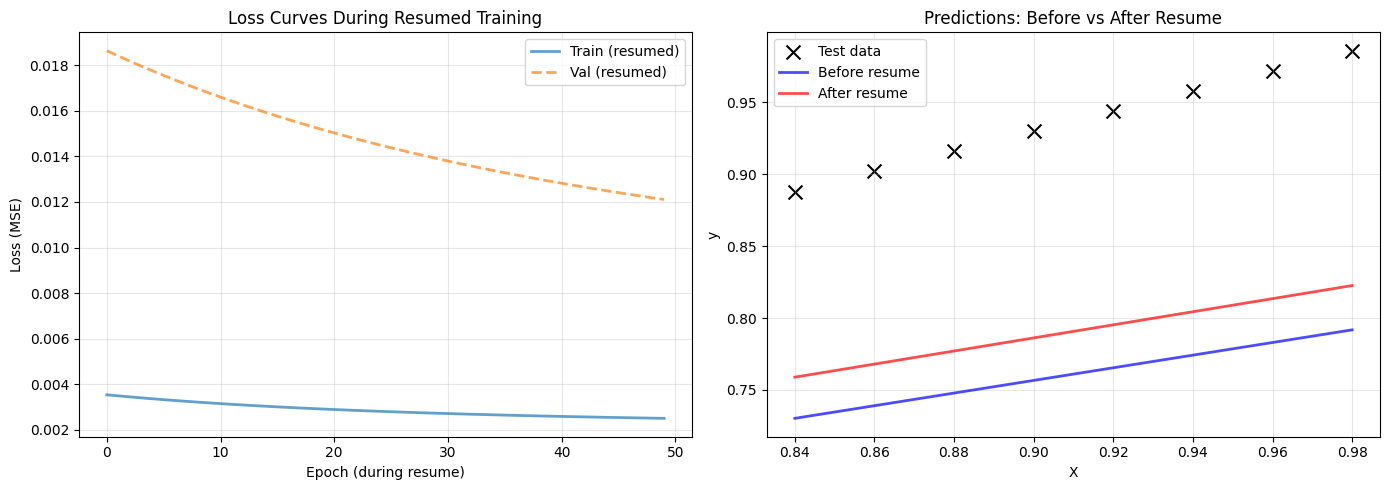

Training successfully resumed and verified!


In [7]:
# Load checkpoint
resume_checkpoint = torch.load(checkpoint_path)
resume_epoch = resume_checkpoint['epoch']
print(f"Loading checkpoint from epoch {resume_epoch}")

# Create model and restore state
resume_model = LinearRegressionModel()
resume_model.load_state_dict(resume_checkpoint['model_state_dict'])

# Create optimizer and restore its state
resume_optimizer = optim.SGD(resume_model.parameters(), lr=0.01)
resume_optimizer.load_state_dict(resume_checkpoint['optimizer_state_dict'])

print(f"Model weight: {resume_model.weight.item():.4f}")
print(f"Model bias: {resume_model.bias.item():.4f}")

# Track losses during resumed training
resumed_train_losses = []
resumed_val_losses = []

# Continue training from saved epoch
additional_epochs = 50
print(f"\nResuming training for {additional_epochs} more epochs...")

for epoch in range(additional_epochs):
    resume_model.train()
    y_pred_resume = resume_model(X_train)
    loss_resume = criterion(y_pred_resume, y_train)
    resume_optimizer.zero_grad()
    loss_resume.backward()
    resume_optimizer.step()
    resumed_train_losses.append(loss_resume.item())
    
    # Validation loss
    resume_model.eval()
    with torch.no_grad():
        val_pred_resume = resume_model(X_val)
        val_loss_resume = criterion(val_pred_resume, y_val)
    resumed_val_losses.append(val_loss_resume.item())

print(f"Resumed training complete!")
print(f"Model weight after resume: {resume_model.weight.item():.4f}")
print(f"Model bias after resume: {resume_model.bias.item():.4f}")

# Verify continued training - compare predictions before and after
resume_model.eval()
with torch.no_grad():
    resumed_test_preds = resume_model(X_test)
    resumed_test_loss = criterion(resumed_test_preds, y_test).item()

print(f"\nVerification:")
print(f"  Original test loss: {test_loss.item():.6f}")
print(f"  Resumed test loss: {resumed_test_loss:.6f}")
print(f"  Loss improved: {resumed_test_loss < test_loss.item()}")

# Visualize training continuation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves during resumed training
ax1.plot(resumed_train_losses, label='Train (resumed)', linewidth=2, alpha=0.7)
ax1.plot(resumed_val_losses, label='Val (resumed)', linewidth=2, linestyle='--', alpha=0.7)
ax1.set_xlabel('Epoch (during resume)')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Curves During Resumed Training')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Predictions comparison
ax2.scatter(X_test.numpy(), y_test.numpy(), c='k', marker='x', label='Test data', s=100)
ax2.plot(X_test.numpy(), test_predictions.numpy(), 'b-', linewidth=2, label='Before resume', alpha=0.7)
ax2.plot(X_test.numpy(), resumed_test_preds.numpy(), 'r-', linewidth=2, label='After resume', alpha=0.7)
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.set_title('Predictions: Before vs After Resume')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Training successfully resumed and verified!")